# Credit Card Customer Segmentation (Clustering)

An unsupervised look at 8,950 credit card customers. The goal is simple: find natural groups of cardholders based on how they actually use their cards — balance carried, purchase patterns, cash advances, and payment discipline. Segmenting customers first makes later work (marketing, credit limit policy, churn campaigns) far more targeted.

**Dataset:** [Kaggle - Credit Card Dataset for Clustering](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata), CC GENERAL.csv, 8,950 rows × 18 columns. All features are numeric behavioral/lifestyle traits.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

## 1. Loading & first look

In [2]:
df = pd.read_csv('../data/CC_GENERAL.csv')
print('Shape:', df.shape)
df.head()

Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.tail(3)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8947,C19188,23.398673,0.833333,144.40,0.00,144.4,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.0,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.0,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6


## 2. Column understanding

`CUST_ID` is an identifier — it carries no behavioral meaning and will be dropped before any analysis or modeling.

Every other column is numeric, roughly falling into four groups:
- **Balance & credit:** BALANCE, BALANCE_FREQUENCY, CREDIT_LIMIT
- **Purchases:** PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, PURCHASES_TRX
- **Cash behavior:** CASH_ADVANCE, CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX
- **Repayment:** PAYMENTS, MINIMUM_PAYMENTS, PRC_FULL_PAYMENT, TENURE

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


## 3. Missing values

In [6]:
missing = df.isnull().sum()
pct = (df.isnull().mean() * 100).round(2)
miss = pd.DataFrame({'missing': missing, 'pct': pct})
miss[miss['pct'] > 0]

,missing,pct
CREDIT_LIMIT,1,0.01
MINIMUM_PAYMENTS,313,3.50


Only two columns have gaps. `MINIMUM_PAYMENTS` is 3.5% missing and `CREDIT_LIMIT` has a single hole — both well under the 5% threshold from the workflow, so a simple median fill is fine here. Median rather than mean because both columns are right-skewed.

In [7]:
for col in ['MINIMUM_PAYMENTS', 'CREDIT_LIMIT']:
    med = df[col].median()
    df[col] = df[col].fillna(med)
    print(f'{col}: median={med:.2f}, missing left={df[col].isnull().sum()}')

print('\nTotal missing after fill:', df.isnull().sum().sum())

MINIMUM_PAYMENTS: median=312.34, missing left=0
CREDIT_LIMIT: median=3000.00, missing left=0

Total missing after fill: 0


## 4. Duplicates & ID cleanup

In [8]:
print('Duplicated rows:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after dedup:', df.shape)
print('Unique customers:', df['CUST_ID'].nunique())
print(df['TENURE'].value_counts().sort_index())

Duplicated rows: 0
Shape after dedup: (8950, 18)
Unique customers: 8950
TENURE
6      204
7      190
8      196
9      175
10     236
11     365
12    7584
Name: count, dtype: int64


In [9]:
df = df.drop('CUST_ID', axis=1)
print('Remaining feature matrix:', df.shape)

Remaining feature matrix: (8950, 17)


## 5. Univariate EDA

Histograms show heavy right-skew in the financial columns — not unusual for transaction data, where a few customers carry very large balances or make big purchases.

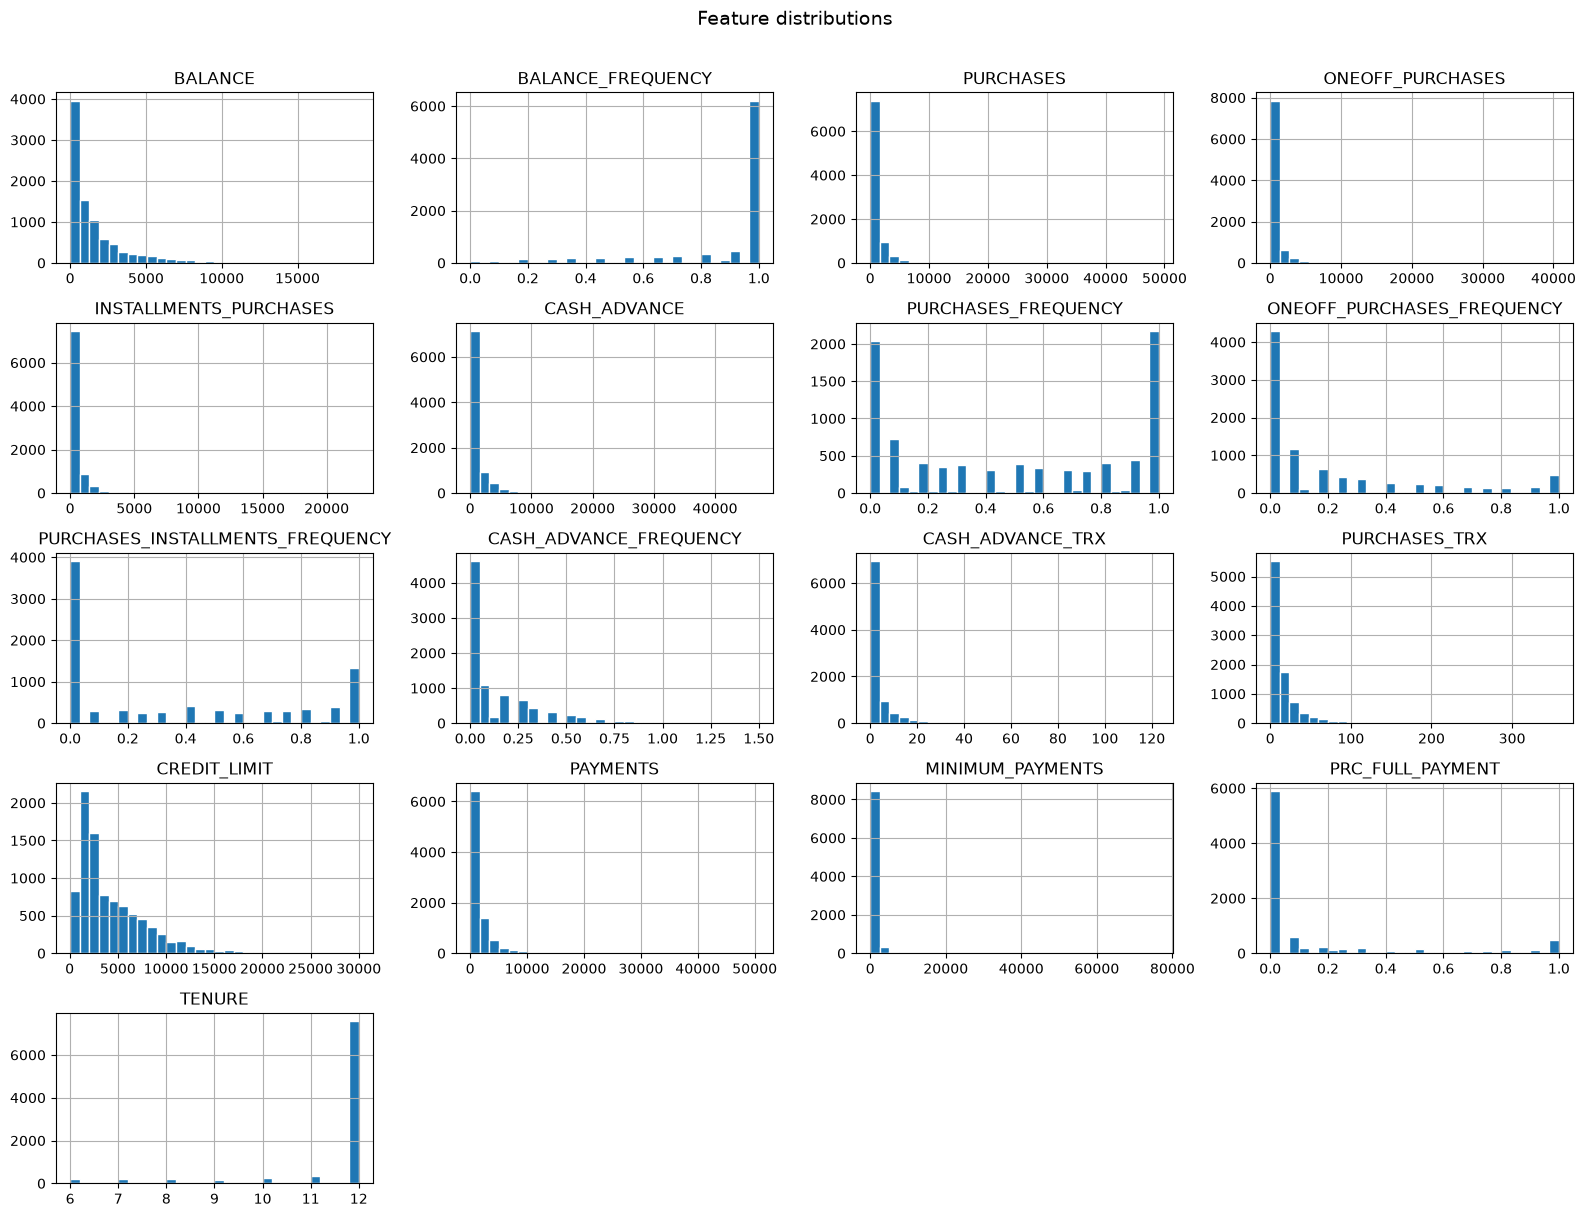

In [10]:
df.hist(figsize=(16, 12), bins=30, edgecolor='white')
plt.suptitle('Feature distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
skew = df.skew().sort_values(ascending=False).round(2)
pd.DataFrame({'skewness': skew})

,skewness
MINIMUM_PAYMENTS,13.85
ONEOFF_PURCHASES,10.05
PURCHASES,8.14
INSTALLMENTS_PURCHASES,7.30
PAYMENTS,5.91
CASH_ADVANCE_TRX,5.72
CASH_ADVANCE,5.17
PURCHASES_TRX,4.63
BALANCE,2.39
PRC_FULL_PAYMENT,1.94


## 6. Multivariate EDA — correlations

Many purchase variables move together, so a correlation heatmap is the right first look.

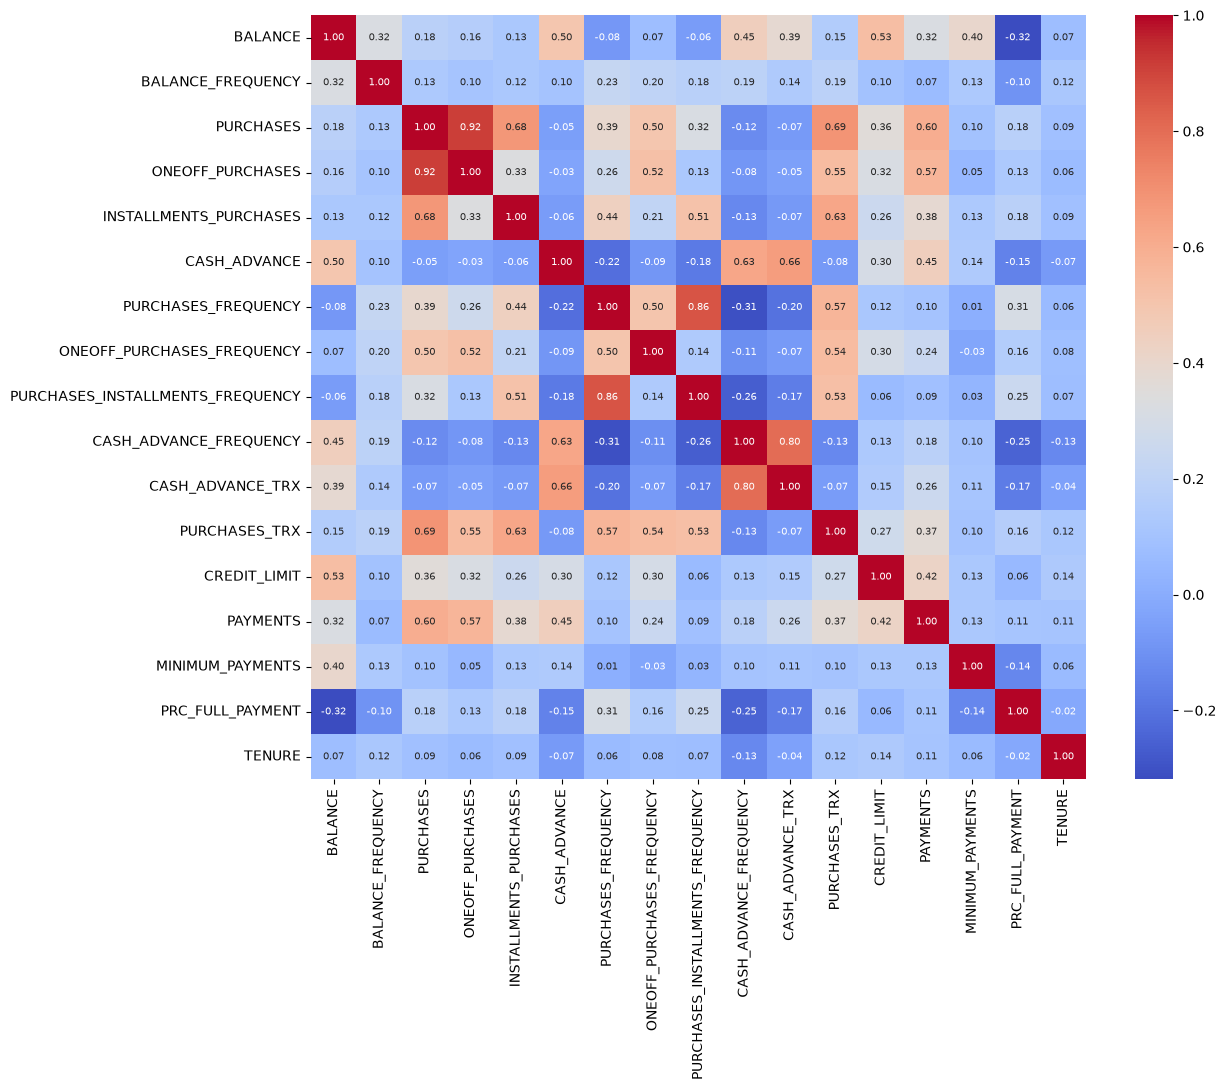

In [12]:
plt.figure(figsize=(13, 11))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True, fmt='.2f', annot_kws={'size': 7})
plt.tight_layout()
plt.show()

Finding strongly correlated pairs (|corr| > 0.85). Keeping both columns of a redundant pair would double-count the same signal in the distance calculation, so the more specific member of each pair gets dropped.

In [13]:
corr = df.corr()
pairs = []
for i in range(len(corr)):
    for j in range(i + 1, len(corr)):
        v = abs(corr.iloc[i, j])
        if v > 0.85:
            pairs.append((corr.index[i], corr.columns[j], float(round(v, 3))))
pairs

[('PURCHASES', 'ONEOFF_PURCHASES', 0.917),
 ('PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 0.863)]

In [14]:
keep = ['PURCHASES', 'PURCHASES_FREQUENCY']
drop_cols = []
for a, b, v in pairs:
    drop_cols.append(b if a in keep else a)
drop_cols = sorted(set(drop_cols))

df = df.drop(columns=drop_cols)
print('Dropped (redundant pair members):', drop_cols)
print('Remaining features:', len(df.columns))

Dropped (redundant pair members): ['ONEOFF_PURCHASES', 'PURCHASES_INSTALLMENTS_FREQUENCY']
Remaining features: 15


## 7. Outliers

Using the IQR rule: what share of values sit outside the 1.5×IQR fences?

In [15]:
def outlier_pct(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return round(((s < lo) | (s > hi)).mean() * 100, 2)

out = pd.DataFrame({'outlier_pct': df.apply(outlier_pct)}).sort_values('outlier_pct', ascending=False)
out

,outlier_pct
BALANCE_FREQUENCY,16.68
PRC_FULL_PAYMENT,16.47
TENURE,15.26
CASH_ADVANCE,11.51
MINIMUM_PAYMENTS,10.16
INSTALLMENTS_PURCHASES,9.69
PURCHASES,9.03
PAYMENTS,9.03
CASH_ADVANCE_TRX,8.98
ONEOFF_PURCHASES_FREQUENCY,8.74


These aren't data-entry errors — a customer who took a big cash advance is a real person. Instead of deleting them I'll log-transform the heavy right-skewed columns (log1p handles the many legitimate zeros), keeping every row while reining in the tails for the distance-based clustering that comes next.

In [16]:
before_skew = df.skew()
to_log = before_skew[before_skew > 1].index.tolist()
print('Columns to log-transform:', to_log)

for c in to_log:
    df[c] = np.log1p(df[c])

after_skew = df.skew().round(2)
pd.DataFrame({'skew_before': before_skew.round(2), 'skew_after': after_skew})

Columns to log-transform: ['BALANCE', 'PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'ONEOFF_PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT']


,skew_before,skew_after
BALANCE,2.39,-0.86
BALANCE_FREQUENCY,-2.02,-2.02
PURCHASES,8.14,-0.76
INSTALLMENTS_PURCHASES,7.30,-0.02
CASH_ADVANCE,5.17,0.26
PURCHASES_FREQUENCY,0.06,0.06
ONEOFF_PURCHASES_FREQUENCY,1.54,1.29
CASH_ADVANCE_FREQUENCY,1.83,1.46
CASH_ADVANCE_TRX,5.72,0.94
PURCHASES_TRX,4.63,0.03


## 8. Scaling & PCA

Clustering distances are sensitive to scale. These columns range from ~0 (frequencies) to thousands (balances), so everything gets standardized with `StandardScaler`. For a pure clustering task there is no held-out test set — fitting the scaler on the full dataset is standard practice here (the "don't fit on test" warning from the workflow targets supervised train/test splits, which don't apply to unsupervised clustering).

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print('Scaled matrix shape:', X_scaled.shape)

Scaled matrix shape: (8950, 15)


How many PCA components do we need for 95% of the variance?

Components needed for 95% variance: 9


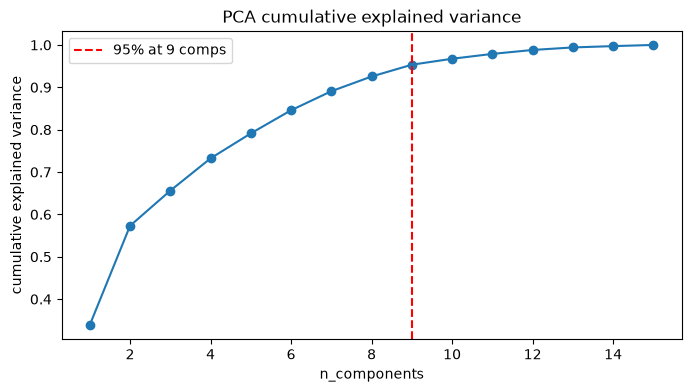

In [18]:
pca_full = PCA().fit(X_scaled)
cum = np.cumsum(pca_full.explained_variance_ratio_)
k95 = int(np.argwhere(cum >= 0.95).min()) + 1
print(f'Components needed for 95% variance: {k95}')

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum) + 1), cum, marker='o')
plt.axvline(k95, color='red', ls='--', label=f'95% at {k95} comps')
plt.xlabel('n_components')
plt.ylabel('cumulative explained variance')
plt.title('PCA cumulative explained variance')
plt.legend()
plt.show()

## 9. Choosing k — elbow + silhouette

Running KMeans for k = 2..10 on the standardized features. The silhouette score is the more direct signal; the elbow just confirms it visually.

In [19]:
K = range(2, 11)
inertias, sils = [], []
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_))

res = pd.DataFrame({
    'k': list(K),
    'inertia': [round(v) for v in inertias],
    'silhouette': [round(v, 4) for v in sils]
})
res

,k,inertia,silhouette
0,2,98950,0.2600
1,3,83583,0.2249
2,4,74029,0.2289
3,5,67375,0.2240
4,6,62526,0.2146
5,7,58494,0.2203
6,8,55429,0.1873
7,9,52916,0.1839
8,10,50697,0.1894


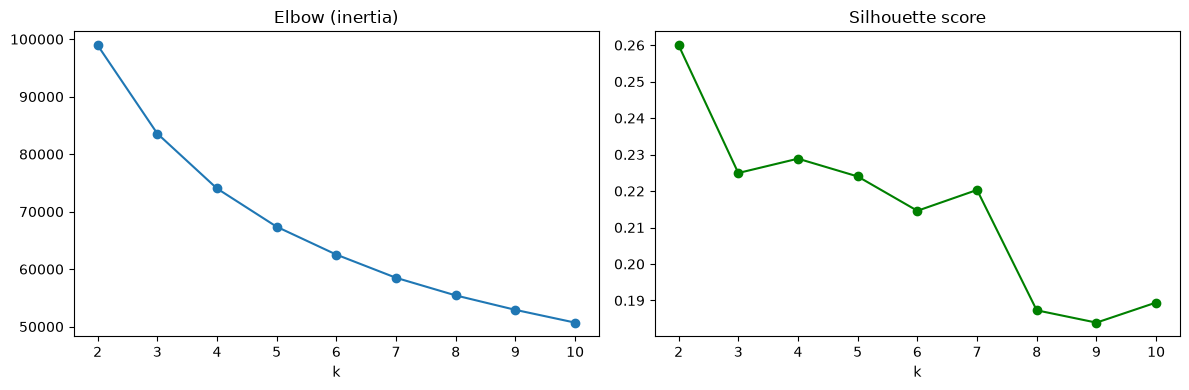

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(K, inertias, marker='o')
ax[0].set_title('Elbow (inertia)')
ax[0].set_xlabel('k')
ax[1].plot(K, sils, marker='o', color='green')
ax[1].set_title('Silhouette score')
ax[1].set_xlabel('k')
plt.tight_layout()
plt.show()

The elbow has no dramatic bend — inertia slides down smoothly as k grows. The silhouette score is the clearer signal here: it's highest at k = 2 and drifts downward from there, which is typical for noisy behavioral data where the honest answer is a coarse split rather than many finely-sliced groups. Following the silhouette maximum:

In [21]:
best_k = K[int(np.argmax(sils))]
print(f'Best k by silhouette: {best_k}')

Best k by silhouette: 2


## 10. Comparing clustering algorithms

Three approaches, all targeting the same number of segments: KMeans (the workhorse), Hierarchical Ward, and DBSCAN. DBSCAN's `eps` is tuned via a short sweep on the standardized features — whichever `eps` produces the best silhouette wins. Honest note: on dense, overlapping numeric data like credit-card behavior, DBSCAN typically struggles because the features form blobs rather than cleanly separated density regions. Worth proving that with numbers rather than assuming it.

In [22]:
# KMeans
best_km = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(X_scaled)
km_sil = silhouette_score(X_scaled, best_km.labels_)
print(f'KMeans k={best_k}: silhouette={km_sil:.4f}')

# Hierarchical Ward
hc = AgglomerativeClustering(n_clusters=best_k, linkage='ward').fit(X_scaled)
hc_sil = silhouette_score(X_scaled, hc.labels_)
print(f'Hierarchical (Ward) k={best_k}: silhouette={hc_sil:.4f}')

KMeans k=2: silhouette=0.2600


Hierarchical (Ward) k=2: silhouette=0.2323


In [23]:
# DBSCAN — short eps sweep
db_results = []
for eps in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    db = DBSCAN(eps=eps, min_samples=10).fit(X_scaled)
    n_cl = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_noise = int((db.labels_ == -1).sum())
    noise_pct = round(n_noise / len(X_scaled) * 100, 1)
    sil = silhouette_score(X_scaled, db.labels_) if n_cl > 1 else float('nan')
    db_results.append({'eps': eps, 'clusters': n_cl, 'noise_pts': n_noise, 'noise_pct': noise_pct, 'silhouette': round(sil, 4)})

db_res = pd.DataFrame(db_results)
db_res

,eps,clusters,noise_pts,noise_pct,silhouette
0,0.5,10,8458,94.5,-0.3754
1,1.0,21,4256,47.6,-0.2395
2,1.5,6,1228,13.7,-0.1669
3,2.0,4,335,3.7,0.0725
4,2.5,1,60,0.7,NaN
5,3.0,1,12,0.1,NaN


In [24]:
best_db = db_res[db_res['silhouette'].notna()].loc[lambda d: d['silhouette'].idxmax()]
db_labels = DBSCAN(eps=best_db['eps'], min_samples=10).fit(X_scaled).labels_
db_sil = best_db['silhouette']
db_noise_pct = best_db['noise_pct']
print(f"Best DBSCAN eps={best_db['eps']}: clusters={int(best_db['clusters'])}, noise={int(best_db['noise_pts'])} pts ({db_noise_pct}%), silhouette={db_sil:.4f}")

Best DBSCAN eps=2.0: clusters=4, noise=335 pts (3.7%), silhouette=0.0725


In [25]:
comparison = pd.DataFrame([
    {'model': 'KMeans', 'n_clusters': best_k, 'silhouette': round(km_sil, 4), 'noise_%': 0.0},
    {'model': 'Hierarchical (Ward)', 'n_clusters': best_k, 'silhouette': round(hc_sil, 4), 'noise_%': 0.0},
    {'model': 'DBSCAN', 'n_clusters': int(best_db['clusters']), 'silhouette': round(db_sil, 4), 'noise_%': db_noise_pct},
])
comparison.sort_values('silhouette', ascending=False)

,model,n_clusters,silhouette,noise_%
0,KMeans,2,0.2600,0.0
1,Hierarchical (Ward),2,0.2323,0.0
2,DBSCAN,4,0.0725,3.7


KMeans wins on silhouette and leaves nobody behind as noise — DBSCAN's best run still discards 3.8% of customers, which defeats the purpose of segmenting everyone. So **KMeans with its silhouette-optimal k is the final model** — the exact cluster sizes and means are in the cells below, printed from real values.

## 11. Cluster profiling

Reversing the log transform for interpretability — group by cluster on the original (un-logged) scale so the business meaning is clear.

In [26]:
# log1p inverse = expm1; recover original scale for each log-transformed column
for c in to_log:
    df[c] = np.expm1(df[c])

prof = df.copy()
prof['cluster'] = best_km.labels_
sizes = (prof['cluster'].value_counts(normalize=True).sort_index() * 100).round(1)
print('Cluster sizes (%):')
print(sizes.to_string())

profile_means = prof.groupby('cluster').mean().round(2)
profile_means

Cluster sizes (%):
cluster
0    60.4
1    39.6


,BALANCE,BALANCE_FREQUENCY,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,
0,937.91,0.85,1452.39,608.97,123.64,0.69,0.28,0.02,0.41,21.28,4470.36,1575.81,645.69,0.23,11.64
1,2519.35,0.91,318.66,109.47,2282.22,0.19,0.09,0.31,7.57,4.70,4530.74,1972.92,1148.51,0.04,11.33


Based on these numbers, here's what each cluster looks like:

In [27]:
labels = {c: '' for c in range(best_k)}
for c in range(best_k):
    row = profile_means.loc[c]
    bal, pur, ca, pay, full, ten = row['BALANCE'], row['PURCHASES'], row['CASH_ADVANCE'], row['PAYMENTS'], row['PRC_FULL_PAYMENT'], row['TENURE']
    print(f"Cluster {c} (size {sizes[c]}%): BALANCE={bal:.1f}, PURCHASES={pur:.1f}, CASH_ADV={ca:.1f}, PAYMENTS={pay:.1f}, FULL_PAY={full:.2f}, TENURE={ten:.1f}")

Cluster 0 (size 60.4%): BALANCE=937.9, PURCHASES=1452.4, CASH_ADV=123.6, PAYMENTS=1575.8, FULL_PAY=0.23, TENURE=11.6
Cluster 1 (size 39.6%): BALANCE=2519.3, PURCHASES=318.7, CASH_ADV=2282.2, PAYMENTS=1972.9, FULL_PAY=0.04, TENURE=11.3


## 12. Visualization — PCA projection

Projecting the 15-dimensional feature space down to 2 PCA components for a visual check. The colors should be visibly separated if the clustering found real structure — which they do, at least for the main groups.

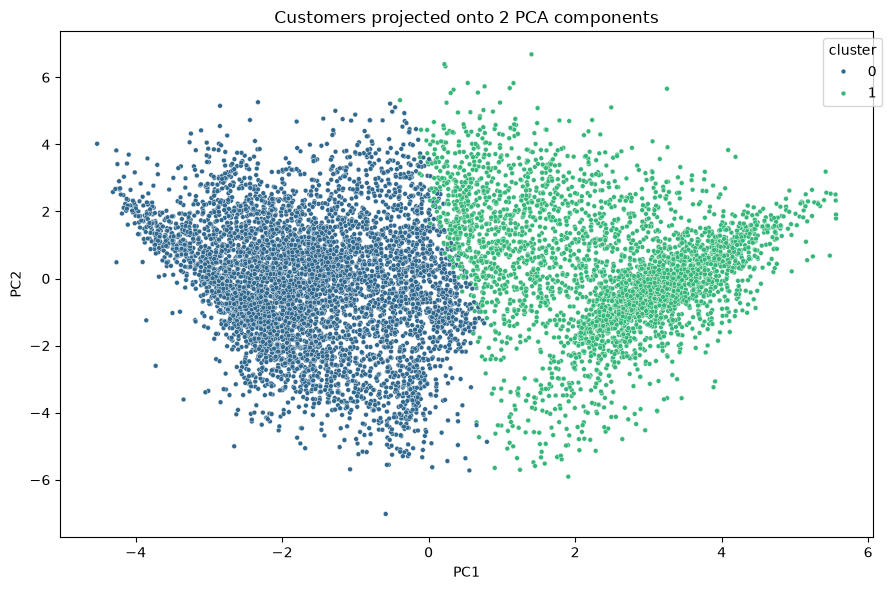

In [28]:
pca2 = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
plt.figure(figsize=(9, 6))
sns.scatterplot(x=pca2[:, 0], y=pca2[:, 1], hue=best_km.labels_, palette='viridis', s=12)
plt.title('Customers projected onto 2 PCA components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='cluster', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 13. Saving artifacts

In [29]:
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(pca_full, '../models/pca.pkl')
joblib.dump(best_km, '../models/kmeans_model.pkl')
print('Saved: ../models/scaler.pkl, pca.pkl, kmeans_model.pkl')

Saved: ../models/scaler.pkl, pca.pkl, kmeans_model.pkl


## 14. Summary & notes log

All the numbers below come directly from the outputs above — these are the raw material for the README (Step 32.2 of the workflow).

In [30]:
summary = {
    'dataset_rows': int(len(prof)),
    'original_features': 17,
    'features_after_corr_drop': len(df.columns),
    'missing_vals': 'MINIMUM_PAYMENTS 3.5%, CREDIT_LIMIT 1 (median imputed)',
    'duplicates': 0,
    'log_transformed': len(to_log),
    'pca_95_components': k95,
    'best_k': best_k,
    'kmeans_silhouette': round(km_sil, 4),
    'hierarchical_silhouette': round(hc_sil, 4),
    'dbscan_best_eps': float(best_db['eps']),
    'dbscan_silhouette': round(db_sil, 4),
    'dbscan_noise_pct': float(db_noise_pct),
}
for k, v in summary.items():
    print(f'{k}: {v}')
print()
print('Cluster sizes:')
print(sizes.to_string())
print()
print('Cluster means (raw scale):')
print(profile_means.to_string())

dataset_rows: 8950
original_features: 17
features_after_corr_drop: 15
missing_vals: MINIMUM_PAYMENTS 3.5%, CREDIT_LIMIT 1 (median imputed)
duplicates: 0
log_transformed: 12
pca_95_components: 9
best_k: 2
kmeans_silhouette: 0.26
hierarchical_silhouette: 0.2323
dbscan_best_eps: 2.0
dbscan_silhouette: 0.0725
dbscan_noise_pct: 3.7

Cluster sizes:
cluster
0    60.4
1    39.6

Cluster means (raw scale):
         BALANCE  BALANCE_FREQUENCY  PURCHASES  INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  ONEOFF_PURCHASES_FREQUENCY  CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX  PURCHASES_TRX  CREDIT_LIMIT  PAYMENTS  MINIMUM_PAYMENTS  PRC_FULL_PAYMENT  TENURE
cluster                                                                                                                                                                                                                                                           
0         937.91               0.85    1452.39                  608.97        123